### This notebook is intended to produce the plots related to the extensive benchmark realized in the paper 

In [2]:
### library imports

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import numpy as np 

from scipy.stats import pearsonr

### open dataframes 
df = pd.read_json('main_results_extensive/extensive_benchmark_hardware.json', orient='records', lines=True)
df_kernels = pd.read_json('main_results_extensive/P_kernels_hardness_drop_hardware.json', orient='records', lines=True)


#### Some data about the problem instances: 

In [3]:
min(df['hardness parameter']), max(df['hardness parameter'])

(1.0325385746, 9716.7627521482)

In [4]:
min(df['N']), max(df['N'])

(7, 231)

### 1. Figure of PMIS as a function of the hardness parameter


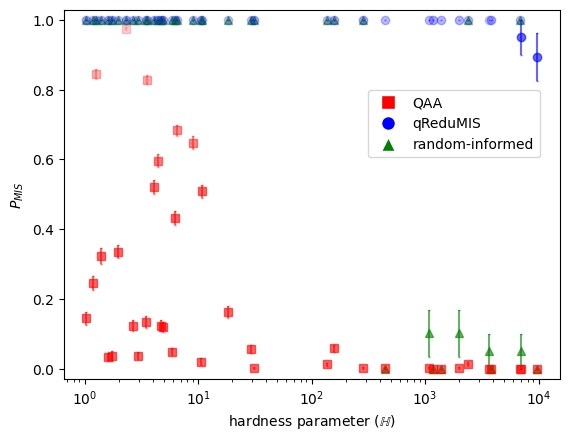

In [5]:
jitter_amount = 0.03  # Adjust this value as needed
df['PMIS random mean jittered'] = df['PMIS random mean']
df.loc[df['PMIS random mean'] == 1, 'PMIS random mean jittered'] += np.random.uniform(-jitter_amount, jitter_amount, size=df[df['PMIS random mean'] == 1].shape[0])

jitter_amount = -0.01  # Adjust this value as needed
df['PMIS qReduMIS mean jittered'] = df['PMIS qReduMIS mean']
df.loc[df['PMIS qReduMIS mean'] == 1, 'PMIS qReduMIS mean jittered'] += np.random.uniform(-jitter_amount, jitter_amount, size=df[df['PMIS qReduMIS mean'] == 1].shape[0])


alpha_values_qReduMIS = 1.0 - 0.8 * (df['PMIS qReduMIS mean jittered'] - df['PMIS qReduMIS mean jittered'].min()) / (df['PMIS qReduMIS mean jittered'].max() - df['PMIS qReduMIS mean jittered'].min())
alpha_values_qReduMIS = np.clip(alpha_values_qReduMIS, 0.2, 0.6)  # Ensure alpha is between 0.1 and 1.0

alpha_values_random = 1.0 - 0.8 * (df['PMIS random mean jittered'] - df['PMIS random mean jittered'].min()) / (df['PMIS random mean jittered'].max() - df['PMIS random mean jittered'].min())
alpha_values_random = np.clip(alpha_values_random, 0.5, 0.6)  # Ensure alpha is between 0.1 and 1.0


alpha_values_QAA = 1.0 - 0.8 * (df['PMIS QAA mean'] - df['PMIS QAA mean'].min()) / (df['PMIS QAA mean'].max() - df['PMIS QAA mean'].min())
alpha_values_QAA= np.clip(alpha_values_QAA, 0.2, 0.6)  # Ensure alpha is between 0.1 and 1.0


for i in range(len(df)):
    plt.errorbar(
        df['hardness parameter'].iloc[i],
        df['PMIS random mean'].iloc[i],
        yerr=df['PMIS random std'].iloc[i],
        fmt='^',
        capsize=1,
        color='green',
        alpha=alpha_values_random.iloc[i],
    )

    plt.errorbar(
        df['hardness parameter'].iloc[i], 
        df['PMIS QAA mean'].iloc[i],
        yerr=df['PMIS QAA std'].iloc[i], 
        fmt='s', 
        capsize=1, 
        label="QAA", 
        color="red",
        alpha=alpha_values_QAA.iloc[i])

    plt.errorbar(df['hardness parameter'].iloc[i],
        df['PMIS qReduMIS mean'].iloc[i], 
        yerr=df['PMIS qReduMIS std'].iloc[i], 
        fmt='o', 
        capsize=1, 
        label="qReduMIS", 
        color="blue",
        alpha=alpha_values_qReduMIS.iloc[i])

legend_marker_random = Line2D([0], [0], marker='^', color='w', label='random-informed',
                       markerfacecolor='green', markersize=10, alpha=1.0)

legend_marker_QAA = Line2D([0], [0], marker='s', color='w', label='QAA',
markerfacecolor='red', markersize=10, alpha=1.0)

legend_marker_qReduMIS = Line2D([0], [0], marker='o', color='w', label='qReduMIS',
markerfacecolor='blue', markersize=10, alpha=1.0)

plt.xlabel('hardness parameter ($\mathbb{H}$)')
plt.ylabel('$P_{MIS}$')
plt.legend(handles=[legend_marker_QAA, legend_marker_qReduMIS, legend_marker_random], loc='upper left', bbox_to_anchor=(0.6, 0.8)) #legend_marker_random
plt.ylim([-0.03, 1.03])
plt.xscale('log')
#plt.savefig('PMIS_vs_hardness_hardware.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

#### Some small analysis where we compare the random baseline and the qReduMIS performance to write in paragraph in paper 

In [6]:
small_df=df[df['PMIS QAA mean']==0]

for index, row in small_df.iterrows():
    print(f"hardness: {row['hardness parameter']},  random: {row['PMIS random mean']}, qReduMIS: {row['PMIS qReduMIS mean']}")

hardness: 6811.4734933036,  random: 1.0, qReduMIS: 1.0
hardness: 7066.6486308528,  random: 0.05, qReduMIS: 0.9500000000000001
hardness: 9716.7627521482,  random: 0.0, qReduMIS: 0.894
hardness: 1367.9706790123,  random: 0.0, qReduMIS: 1.0
hardness: 3633.9248303587,  random: 0.05, qReduMIS: 1.0
hardness: 1172.5339071466,  random: 0.0, qReduMIS: 1.0
hardness: 3828.2553432642,  random: 0.0, qReduMIS: 1.0


In [7]:
small_df=df[df['hardness parameter']>=10**3]

for index, row in small_df.iterrows():
    print(f"hardness: {row['hardness parameter']}, QAA:   {row['PMIS QAA mean']}, random: {row['PMIS random mean']}, qReduMIS: {row['PMIS qReduMIS mean']}")

hardness: 6811.4734933036, QAA:   0.0, random: 1.0, qReduMIS: 1.0
hardness: 2372.1415816327, QAA:   0.014, random: 1.0, qReduMIS: 1.0
hardness: 7066.6486308528, QAA:   0.0, random: 0.05, qReduMIS: 0.9500000000000001
hardness: 1074.7578387458, QAA:   0.003, random: 0.101, qReduMIS: 1.0
hardness: 9716.7627521482, QAA:   0.0, random: 0.0, qReduMIS: 0.894
hardness: 1367.9706790123, QAA:   0.0, random: 0.0, qReduMIS: 1.0
hardness: 1980.3766534392, QAA:   0.003, random: 0.101, qReduMIS: 1.0
hardness: 3633.9248303587, QAA:   0.0, random: 0.05, qReduMIS: 1.0
hardness: 1172.5339071466, QAA:   0.0, random: 0.0, qReduMIS: 1.0
hardness: 3828.2553432642, QAA:   0.0, random: 0.0, qReduMIS: 1.0


### 2. Figure to quantify the number of quantum calls the qReduMIS performs as a function of the problem size

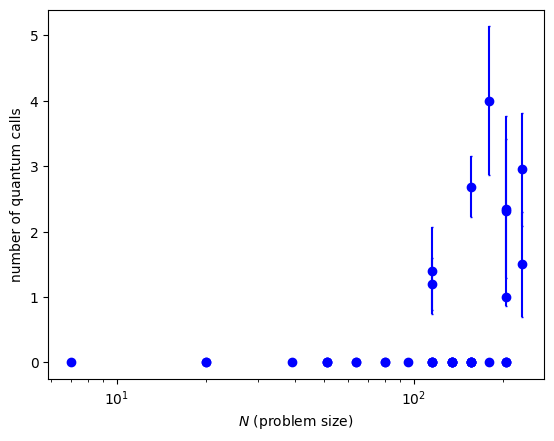

In [8]:
### plot of number of quantum calls vs problem size 

fig, ax = plt.subplots()

ax.errorbar(df['N'], df['quantum calls mean'], yerr=df['quantum calls std'], fmt='o', capsize=1, label="QAA", color='b')
plt.xlabel('$N$ (problem size)')
plt.ylabel('number of quantum calls')
plt.xscale('log')

#plt.savefig('quantum_calls_vs_N.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()

In the paper we report some numbers and particularly some Pearson correlations. Below code get them:

In [10]:
df[(df['hardness parameter']>=10**3) & (df['PMIS qReduMIS mean']<1)].shape  

(2, 15)

In [11]:
## the average first reduction factor among them 

np.round(np.mean(list(df[(df['hardness parameter']>=10**3) & (df['PMIS qReduMIS mean']<1)]['first reduction factor'])),3)

np.float64(0.546)

In [12]:
## the average first reduction factor among all problems considered  

np.round(np.mean(list(df['first reduction factor'])),3)

np.float64(0.902)

In [13]:
np.round(100*(np.mean(list(df[(df['hardness parameter']>=10**3) & (df['PMIS qReduMIS mean']<1)]['first reduction factor']))-np.mean(list(df['first reduction factor'])))/np.mean(list(df['first reduction factor'])),3)

np.float64(-39.416)

In [14]:
## calculate some Pearson correlations 

correlation, p_value = pearsonr(df['PMIS qReduMIS mean'], df['quantum calls mean'])
np.round(correlation,2), np.round(p_value,2)

(np.float64(-0.4), np.float64(0.01))

In [15]:
correlation, p_value = pearsonr(df['PMIS qReduMIS mean'], df['first reduction factor'])
np.round(correlation,2), np.round(p_value,2)

(np.float64(0.45), np.float64(0.0))

In [16]:
correlation, p_value = pearsonr(df['quantum calls mean'], df['first reduction factor'])
np.round(correlation,2), np.round(p_value,2)

(np.float64(-0.92), np.float64(0.0))